In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torchvision import transforms
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch.optim as optim
from sklearn.metrics import accuracy_score, cohen_kappa_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(device)

cuda


Déclaration du modèle et de la fonction d'entrainement 

In [2]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Extraction de features
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 -> 32 canaux
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 224 -> 112

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 -> 64
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 112 -> 56

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 56 -> 28

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 28 -> 14

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 14 -> 7
        )

        # Classifieur
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_one_model(model, train_loader, val_loader, num_epochs, device, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.1, patience=2
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        # ---------- TRAIN ----------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Train", leave=False):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ---------- VAL ----------
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", leave=False):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * correct / total

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"[Epoch {epoch+1}/{num_epochs}] "
              f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.2f}% "
              f"|| Val loss: {val_loss:.4f} | Val acc: {val_acc:.2f}%")

    return model, history

def evaluate_model(model, data_loader, device, class_to_idx):
    model.eval()
    all_labels = []
    all_preds = []

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc   = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds)
    report = classification_report(
        all_labels,
        all_preds,
        target_names=[idx_to_class[i] for i in range(len(idx_to_class))]
    )
    cm = confusion_matrix(all_labels, all_preds)

    return acc, kappa, report, cm

class AnimalDataset(Dataset):
    def __init__(self, dataframe, class_to_idx, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filepath = self.data.iloc[idx, 0]
        animal = self.data.iloc[idx, 1]
        label = self.class_to_idx[animal]

        image = Image.open(filepath).convert("RGB") #On converti les images en RGB pour évité les problèmes de dimention

        if self.transform:
            image = self.transform(image)

        return image, label


In [3]:

data_dir = '../data'

data = []
animal_to_id = {}
id_counter = 0

for animal_folder in os.listdir(data_dir):
    animal_folder_path = os.path.join(data_dir, animal_folder)

    if os.path.isdir(animal_folder_path):

        if animal_folder not in animal_to_id:
            animal_to_id[animal_folder] = id_counter
            id_counter += 1

        for filename in os.listdir(animal_folder_path):
            filepath = os.path.join(animal_folder_path, filename)

            if os.path.isfile(filepath):
                data.append({
                    'filepath': filepath,
                    'animal': animal_folder,
                    'id_animal': animal_to_id[animal_folder]
                })

df = pd.DataFrame(data)

print(df)

                                                filepath   animal  id_animal
0      ../data/chicken/OIP-gUzqQLy58VIRVhf8MEIBOQHaDt...  chicken          0
1      ../data/chicken/OIP-StVieUy8VvwVihLUVW2btQHaLM...  chicken          0
2      ../data/chicken/OIP-_f3wLgkmBejyFdDbR1WguQHaGi...  chicken          0
3      ../data/chicken/OIP-smKDS_EtKGm0mwTp7vD2DwHaHw...  chicken          0
4                              ../data/chicken/1030.jpeg  chicken          0
...                                                  ...      ...        ...
26174  ../data/sheep/OIP-BD1g0-Vy9SiY4TwhtYCefQAAAA.jpeg    sheep          9
26175  ../data/sheep/OIP-gv5fO5xE8Xgv_LggtAeuZwHaH-.jpeg    sheep          9
26176  ../data/sheep/OIP-MZyIkHB_rV4TkK5zMp1pDQHaE7.jpeg    sheep          9
26177  ../data/sheep/OIP-cMMLmBM706xlSEquU6KC3gHaJk.jpeg    sheep          9
26178  ../data/sheep/OIP-_Jf65-HygTUh-HmFlPfWpwHaFj.jpeg    sheep          9

[26179 rows x 3 columns]


In [4]:
X = df['filepath']
y = df['animal']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,        # 60% train, 40% pour val+test
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,        # 20% val, 20% test
    stratify=y_temp,
    random_state=42
)

train_df = pd.DataFrame({'filepath': X_train, 'animal': y_train}) # 60%
val_df   = pd.DataFrame({'filepath': X_val,   'animal': y_val}) # 20%
test_df  = pd.DataFrame({'filepath': X_test,  'animal': y_test}) # 20%

class_to_idx = {animal: idx for idx, animal in enumerate(df['animal'].unique())}
print(class_to_idx)


{'chicken': 0, 'squirrel': 1, 'cat': 2, 'butterfly': 3, 'spider': 4, 'horse': 5, 'cow': 6, 'dog': 7, 'elephant': 8, 'sheep': 9}


In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])


val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

num_classes = len(class_to_idx)
model = SimpleCNN(num_classes=num_classes)
model.to(device)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (

In [6]:
train_dataset = AnimalDataset(train_df, transform=train_transforms, class_to_idx=class_to_idx)
val_dataset = AnimalDataset(val_df, transform=val_transforms, class_to_idx=class_to_idx)
test_dataset = AnimalDataset(test_df, transform=val_transforms, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True, num_workers=8)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=8)

In [7]:
n_runs = 5
num_epochs = 10
results_cnn = []

for run in range(n_runs):
    print(f"\n========== RUN {run+1}/{n_runs} - CNN ==========")

    model_cnn = SimpleCNN(num_classes=len(class_to_idx)).to(device)

    model_cnn, history_cnn = train_one_model(
        model_cnn,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        device=device
    )

    test_acc_cnn, test_kappa_cnn, report_cnn, cm_cnn = evaluate_model(
        model_cnn,
        test_loader,
        device,
        class_to_idx
    )

    results_cnn.append({
        "run": run + 1,
        "test_acc": test_acc_cnn,
        "test_kappa": test_kappa_cnn,
        "history": history_cnn,
        "report": report_cnn,
        "confusion_matrix": cm_cnn
    })

accs_cnn   = [r["test_acc"] for r in results_cnn]
kappas_cnn = [r["test_kappa"] for r in results_cnn]

print("\n=== RÉSUMÉ CNN MAISON ===")
print(f"Accuracy moyenne : {np.mean(accs_cnn):.4f} ± {np.std(accs_cnn):.4f}")
print(f"Kappa moyenne    : {np.mean(kappas_cnn):.4f} ± {np.std(kappas_cnn):.4f}")



========== RUN 1/5 - CNN ==========


[Epoch 1/10] Train loss: 2.1627 | Train acc: 21.68% || Val loss: 1.9458 | Val acc: 31.59%


[Epoch 2/10] Train loss: 1.8288 | Train acc: 35.17% || Val loss: 1.5756 | Val acc: 43.93%


[Epoch 3/10] Train loss: 1.5755 | Train acc: 45.27% || Val loss: 1.3843 | Val acc: 52.04%


[Epoch 4/10] Train loss: 1.3694 | Train acc: 53.01% || Val loss: 1.2712 | Val acc: 56.28%


...

[Epoch 7/10] Train loss: 1.1207 | Train acc: 61.19% || Val loss: 1.0654 | Val acc: 63.39%


[Epoch 8/10] Train loss: 1.0658 | Train acc: 63.44% || Val loss: 1.0840 | Val acc: 63.24%


[Epoch 9/10] Train loss: 0.9918 | Train acc: 66.25% || Val loss: 0.9844 | Val acc: 66.71%


[Epoch 10/10] Train loss: 0.9471 | Train acc: 67.21% || Val loss: 0.9429 | Val acc: 68.56%



=== RÉSUMÉ CNN MAISON ===
Accuracy moyenne : 0.5667 ± 0.1936
Kappa moyenne    : 0.4885 ± 0.2478


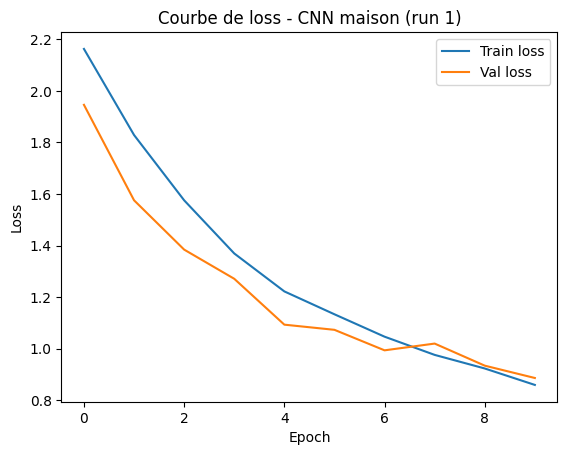

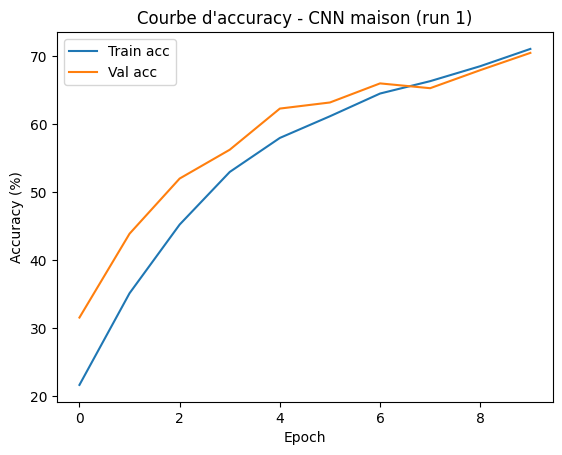

In [8]:

# On prend le premier run CNN comme exemple
hist_cnn = results_cnn[0]["history"]

# Loss
plt.figure()
plt.plot(hist_cnn["train_loss"], label="Train loss")
plt.plot(hist_cnn["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Courbe de loss - CNN maison (run 1)")
plt.legend()
plt.show()

# Accuracy
plt.figure()
plt.plot(hist_cnn["train_acc"], label="Train acc")
plt.plot(hist_cnn["val_acc"], label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Courbe d'accuracy - CNN maison (run 1)")
plt.legend()
plt.show()


In [9]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

def plot_confusion_matrix(cm, class_names, title="Matrice de confusion"):
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar(im)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)
    ax.set_ylabel("Vraies classes")
    ax.set_xlabel("Classes prédites")

    # Optionnel : annotations dans les cases
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.show()

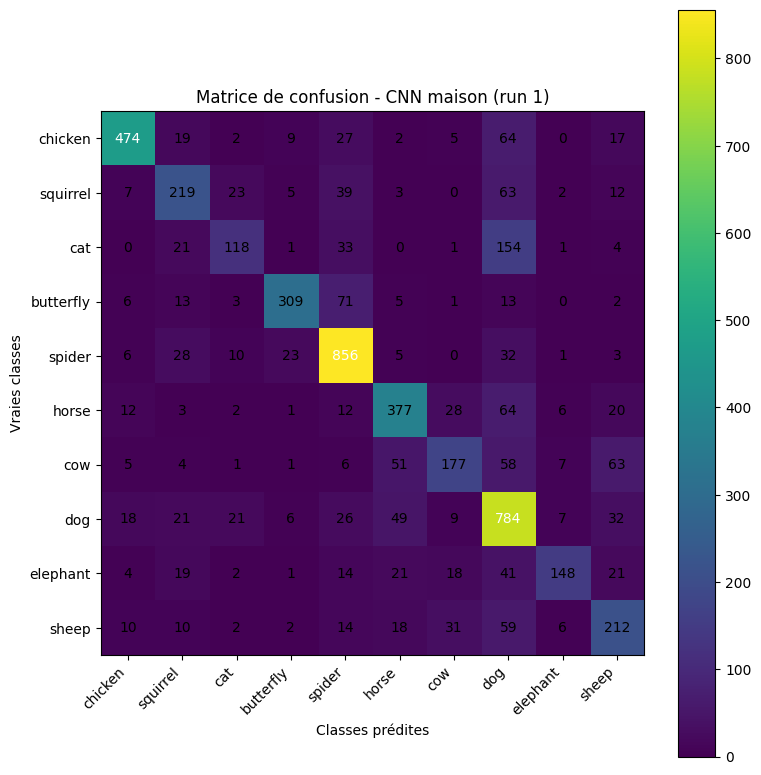

In [10]:
cm_cnn_run1 = results_cnn[0]["confusion_matrix"]
plot_confusion_matrix(
    cm_cnn_run1,
    [idx_to_class[i] for i in range(len(idx_to_class))],
    title="Matrice de confusion - CNN maison (run 1)"
)